# Introduction to Python and data science

<div class="markdown-google-sans">
  <h2>Introduction to Colab</h2>
</div>

Colab is a notebook tool from Google or "Colaboratory", allows you to write and execute Python in your browser, without any installation required on your machine. It comes with some advantages:

1.  Zero configuration required
2.  Access to GPUs free of charge
3.  Easy sharing

For a full Colab tutorial, watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI).




<div class="markdown-google-sans">
  <h2>Workstation setup</h2>
</div>

During the lab, we will be working in Colab and use the lab [GitHub repo](https://github.com/Hertie-School-Deep-Learning-Fall-2023/Lab-Session) to upload and download resources.

Colab comes with most standard Python packages, that you can mostly directly import. For a list of all the available packages, type:

`!pip list command`.

In case you have to install a package (see below), type:

 `!pip install package_name` .










In [ ]:
!pip install selenium

In [ ]:
import selenium

<div class="markdown-google-sans">
  <h2>Recap programming</h2>
</div>

We will start refreshing our programming skills using the notorious [1963 Iris database](https://en.wikipedia.org/wiki/Iris_flower_data_set).

In [ ]:
import pandas as pd
import numpy as np
import numpy.random as rand
from sklearn.datasets import *

In [ ]:
data_dict = load_iris(as_frame=True)
df = data_dict['data']
label = data_dict['target']

<Axes: >

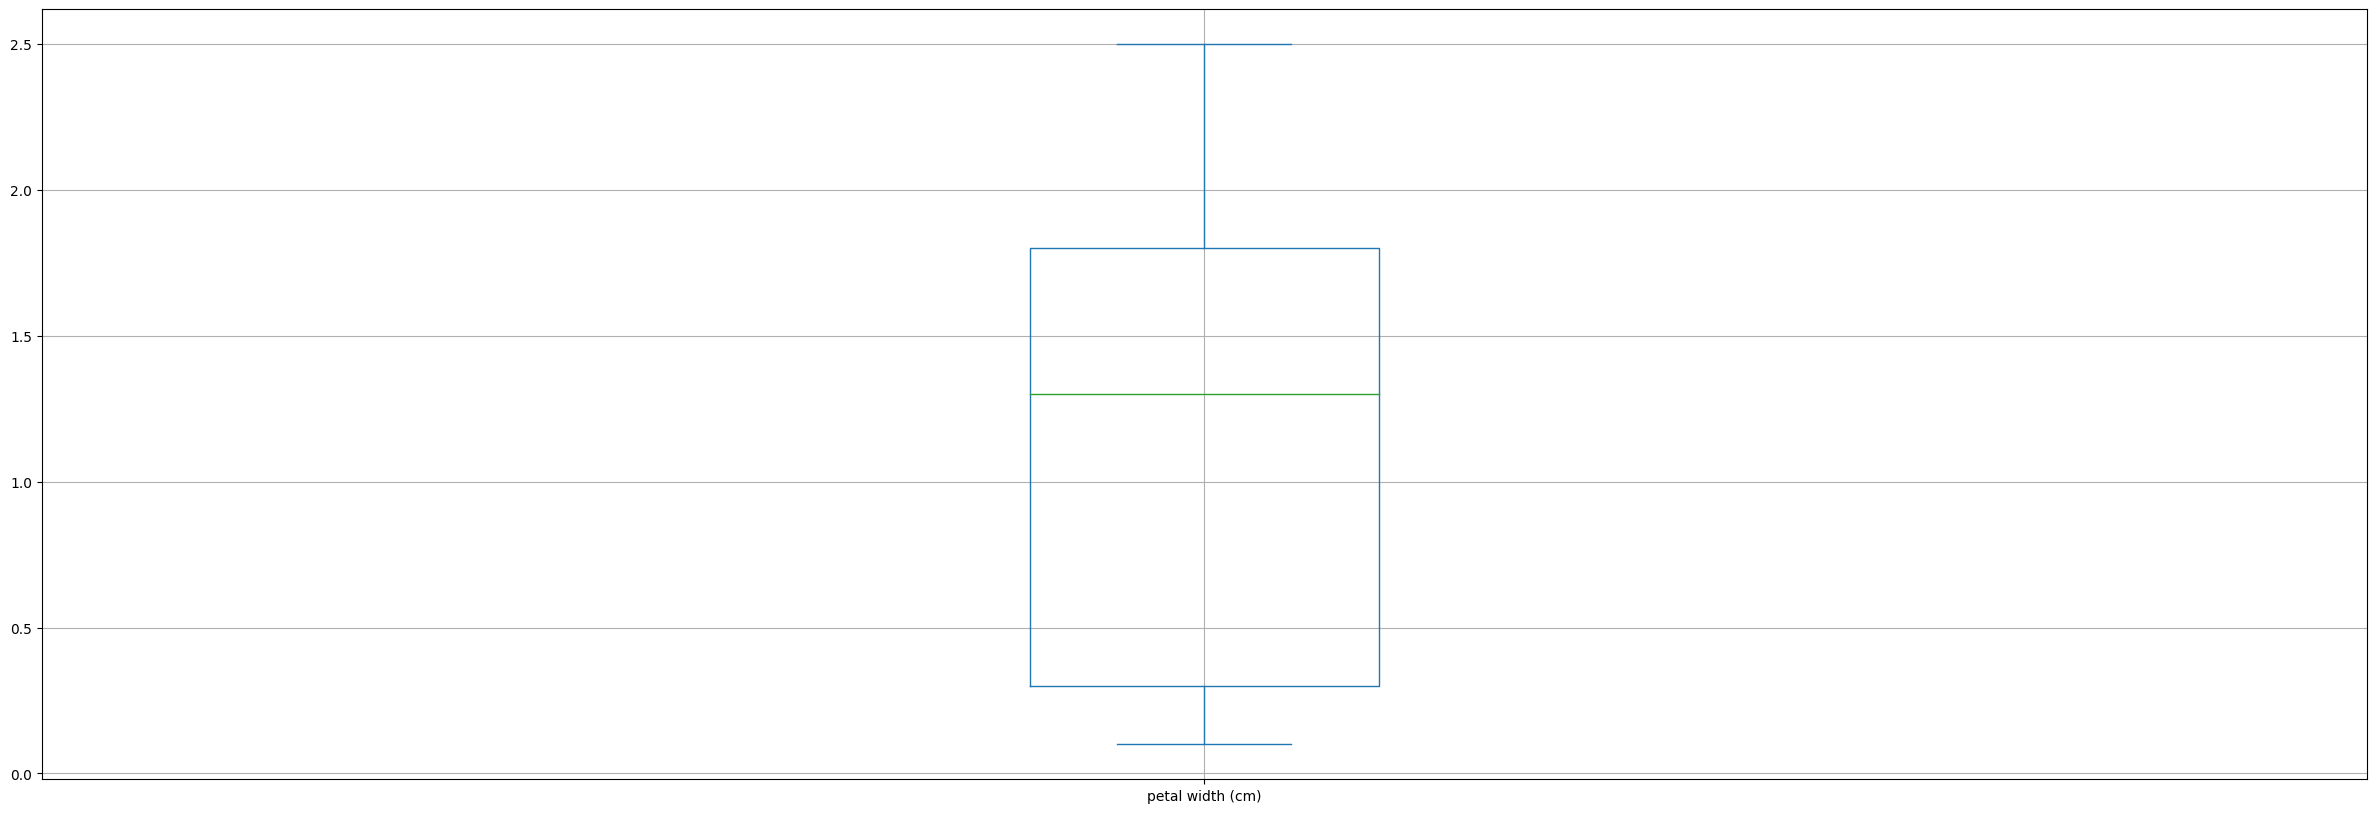

In [ ]:
df['petal width (cm)'].plot.box(figsize=(30,10), grid=True)

In [ ]:
df[df['sepal length (cm)'] <= 5].sort_values(by='sepal length (cm)',ascending=False)

In [ ]:
# @title TASK 1: print the average sepal length (cm) across all observations and its standard deviation.
df['sepal length (cm)'].mean(), df['sepal length (cm)'].min()

(5.843333333333334, 4.3)

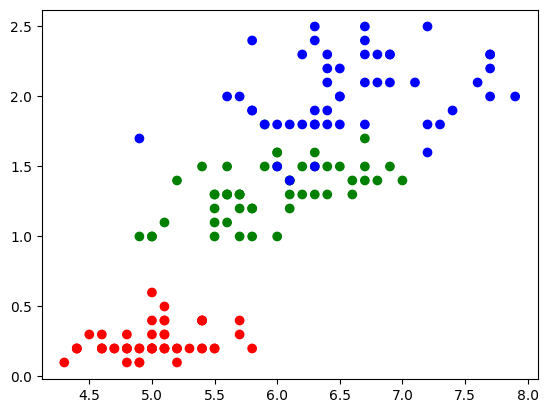

In [ ]:
#@title TASK 2: scatter plot the petal length against its petal width and color each data point according to its label. You may want to import matplotlib or your plotting library of choice.
import matplotlib.pyplot as plt
color = {0:"red", 1:"green", 2:"blue"}
plt.scatter(df['sepal length (cm)'], df['petal width (cm)'], color=label.map(color))


In [ ]:
class Car:
  def __init__(self,brand):
    self.brand = 'ferrari'

brand = 'audi'
car = Car(brand='lambo')
car.brand != brand

True

In [ ]:
class Meal:
#Computes the price of your meal based on the total cost of is ingredients.

  def __init__(self, name, total_price=0):

    self.name = name
    self.ingredients = {}
    self.total_price = total_price


  def add_ingredient(self, ingredient, price=0):
    self.ingredients[ingredient] = price
    self.total_price = self.compute_total_price()

  def compute_total_price(self):
    return sum(price for price in self.ingredients.values())

In [ ]:
##EXAMPLE: compute the price of your morning porridge

Breakfast = Meal('porridge')

Breakfast.add_ingredient('berries',2)
Breakfast.add_ingredient('oat milk',1)
Breakfast.compute_total_price()

AttributeError: 'Meal' object has no attribute 'add_ingredients'

In [ ]:
#@title TASK 3: build method add_ingredients that takes as input a list of ingredients and a list of prices and add them to the meal. The function should also that the length of the two lists is compatible.

def add_ingredients(self, ingredients, prices):
    if len(ingredients) != len(prices):
      return None

    for i in range(len(ingredients)):
      ingredient, price = ingredients[i], prices[i]
      self.add_ingredient(ingredient, price)

In [ ]:
#@title TASK 4: we implement the child class HappyMeal. Add a private attribute to define the meal discount and a private method to apply discount. The discount should be applied when computing final price.


class HappyMeal(Meal):

  def __init__(self, discount=.7):

    super().__init__(name='HappyMeal')

    self.add_ingredient('nuggets', 4)
    self.add_ingredient('fries', 3)
    self.add_ingredient('fanta', 1.99)
    self._discount = discount
    assert (discount >= 0) & (discount <= 1), 'this discount is too high!!'
    self.discounted_price = self.compute_total_price() *self._discount




In [ ]:
hp = HappyMeal(discount=1.1)

AssertionError: this discount is too high!!

<div class="markdown-google-sans">
  <h2>Preprocessing<h2>
</div>

Preprocessing is a crucial step to clean and prepare raw data for modeling. It involves:
<ul>
  <li> cleaning: handling of missing values, duplicates and outliers </li>
  <li> rescaling: conversion of numerical data to new scales (e.g. normalization and standardization), encoding categorical variables (e.g. via dummy variables) </li>
  <li> feature selection and analysis: statistical analysis and visualisation (e.g. histograms, correlation, pairwise scatterplots)</li>
</ul>


In [ ]:
# we load an external dataframe
!mkdir data

!wget https://www.umweltbundesamt.de/sites/default/files/medien/372/dokumente/kraftwerke_de_ab_100_mw_0.xls -P data/

df = pd.read_excel("data/kraftwerke_de_ab_100_mw_0.xls", header=9)

mkdir: cannot create directory ‘data’: File exists
--2024-09-06 17:38:30--  https://www.umweltbundesamt.de/sites/default/files/medien/372/dokumente/kraftwerke_de_ab_100_mw_0.xls
Resolving www.umweltbundesamt.de (www.umweltbundesamt.de)... 185.138.142.181
Connecting to www.umweltbundesamt.de (www.umweltbundesamt.de)|185.138.142.181|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 166912 (163K) [application/vnd.ms-excel]
Saving to: ‘data/kraftwerke_de_ab_100_mw_0.xls.1’

kraftwerke_de_ab_10 100%[===================>] 163.00K   258KB/s    in 0.6s    

2024-09-06 17:38:32 (258 KB/s) - ‘data/kraftwerke_de_ab_100_mw_0.xls.1’ saved [166912/166912]



In [ ]:
#@title TASK 5: Keep only power plants with non NaN Bundesland and fill NaNs in the installed capacity (MW) with an appropriate value. Make a new dataframe containing the installed capacity in MW and dummy columns for the state the units belongs to

processed_df = df.copy()
processed_df = processed_df[['Kraftwerksname / Standort', 'Bundesland', 'Elektrische Bruttoleistung (MW)']]
processed_df.dropna(subset=['Bundesland'], inplace=True)
processed_df['Elektrische Bruttoleistung (MW)'].fillna(0, inplace=True)

bl_dummies = pd.get_dummies(processed_df['Bundesland'])
processed_df = pd.concat([processed_df, bl_dummies], axis=1)
processed_df.head(5)


,Kraftwerksname / Standort,Bundesland,Elektrische Bruttoleistung (MW),BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,Offshore,RP,SH,SL,SN,ST,TH
0,Albatros,Offshore,112.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Albbruck-Dogern / Rhein,BW,108.9,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"Altbach/Deizisau GT A-C, E",BW,305.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Altbach/Deizisau HKW 1,BW,476.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Altbach/Deizisau HKW 2,BW,379.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#@title TASK 5: Rescale each power plant to an installed capacity between 0 and 1. Scaling should be done based on the state (i.e. the smallest power plant for each state has scaled capacity of 0, the biggest of 1)

def min_max_scaler(col):
  vmin, vmax = min(col), max(col)

  return (col - vmin) / (vmax - vmin)

processed_df['Scaled capacity'] = processed_df.groupby('Bundesland', as_index=False, group_keys=False).apply(lambda df: min_max_scaler(df['Elektrische Bruttoleistung (MW)']))

In [ ]:
processed_df.groupby('Bundesland')['Scaled capacity'].max()

,Scaled capacity
Bundesland,
BB,1.0
BE,1.0
BW,1.0
BY,1.0
HB,1.0
HE,1.0
HH,1.0
MV,1.0
NI,1.0
